In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from pickle import dump

Clasificador de Vinos con KNN

Entrena un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas. ¿Podría una IA ayudarte a elegir un vino digno de sommelier?

Cada fila representa un vino. Las columnas describen su composición química:

    fixed acidity, volatile acidity, citric acid

    residual sugar, chlorides

    free sulfur dioxide, total sulfur dioxide

    density, pH, sulphates, alcohol

La columna objetivo es label:

    0 = Baja calidad

    1 = Calidad media

    2 = Alta calidad


In [2]:
url = 'https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv'
df = pd.read_csv(url, sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Actualmente nuestra columna quality guarda valores del 3 al 8, lo que haremos a continuacion sera crear una nueva columna objetivo llamada label que guarde 3 valores discretos para la calidad del vino del 0 al 2, siendo 0 el mas bajo y 2 el mas alto

In [3]:
def quality_label(x):
    if x <= 4:
        return 0  
    elif x <= 6:
        return 1  
    else:
        return 2  

df['label'] = df['quality'].apply(quality_label)

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


Ahora separaremos las variables independientes de las objetivo y despues entrenaremos el modelo

In [5]:
X = df.drop(["label", "quality"], axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

Escalaremos los datos, muy recomendable para los modelos KNN con StandardScaler, debido a que KNN se basa en la distancia entre puntos, es esencial tener escalados los datos para que todas contribuyan equitativamente los datos

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


array([[ 1.7140786 , -1.03945414,  0.91982629, ..., -2.40474133,
        -0.01157227, -1.13322848],
       [-0.64981178, -0.81549291,  0.15197026, ...,  0.70316738,
        -0.4210842 , -0.85363758],
       [ 0.96455238, -1.20742506,  1.0222071 , ...,  0.31467879,
         0.8074516 ,  0.07833209],
       ...,
       [ 0.21502617,  0.97619691, -0.15517216, ...,  0.0556864 ,
        -0.3625825 , -1.31962241],
       [-0.82277936, -0.03162861, -0.10398176, ...,  0.96215978,
        -0.94759954,  0.54431692],
       [-0.88043523,  0.19233261, -0.25755296, ...,  0.57367119,
         0.92445501,  0.73071085]], shape=(320, 11))

Crearemos nuestro modelo

In [13]:
model = KNeighborsClassifier(n_neighbors=14)
model.fit(X_train_scaled, y_train)


,n_neighbors,14
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [15]:

y_pred = model.predict(X_test_scaled)

accuracy_score(y_test, y_pred)

0.828125

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.84      0.97      0.90       256
           2       0.74      0.38      0.50        45

    accuracy                           0.83       320
   macro avg       0.53      0.45      0.47       320
weighted avg       0.78      0.83      0.79       320



El modelo es bastante preciso, aun asi crearemos un bucle del 1 al 20 para testear distintos valores de K y buscar cual tiene mejor accuracy

In [19]:
accuracies = []

for k in range(1,  21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred_k = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_k))

accuracies

[0.834375,
 0.79375,
 0.8,
 0.78125,
 0.78125,
 0.79375,
 0.7875,
 0.784375,
 0.790625,
 0.8,
 0.809375,
 0.81875,
 0.83125,
 0.828125,
 0.8375,
 0.828125,
 0.81875,
 0.8125,
 0.815625,
 0.80625]

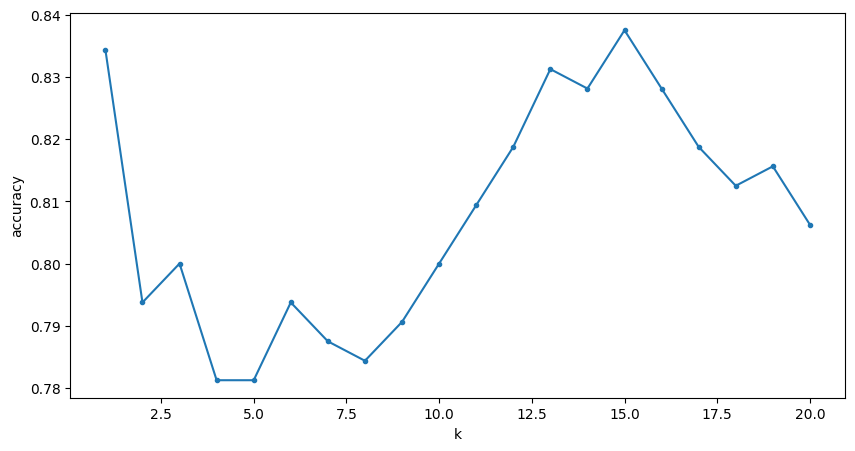

In [25]:

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), accuracies, marker ='.')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.show()

Como podemos observar el valor mas preciso es 15, asi que ahora entrenaremos nuestro modelo con el valor mas optimo

In [27]:
final_model = KNeighborsClassifier(n_neighbors=15)
final_model.fit(X_train_scaled, y_train)

final_y_pred = final_model.predict(X_test_scaled)

In [28]:
accuracy_score(y_test, final_y_pred)

0.8375

Nuestro modelo optimizado tiene un 83,75% de accuracy

In [32]:
with open('modelo_naive-bayes.pkl', 'wb') as file:
    dump(final_model, file)